In [671]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [672]:
data = pd.read_csv('/content/train.csv')
data.head()

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


In [673]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103904 entries, 0 to 103903
Data columns (total 25 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Unnamed: 0                         103904 non-null  int64  
 1   id                                 103904 non-null  int64  
 2   Gender                             103904 non-null  object 
 3   Customer Type                      103904 non-null  object 
 4   Age                                103904 non-null  int64  
 5   Type of Travel                     103904 non-null  object 
 6   Class                              103904 non-null  object 
 7   Flight Distance                    103904 non-null  int64  
 8   Inflight wifi service              103904 non-null  int64  
 9   Departure/Arrival time convenient  103904 non-null  int64  
 10  Ease of Online booking             103904 non-null  int64  
 11  Gate location                      1039

In [674]:
data.drop('Unnamed: 0', axis = 1, inplace=True)

In [675]:
data.isnull().sum()

,0
id,0
Gender,0
Customer Type,0
Age,0
Type of Travel,0
Class,0
Flight Distance,0
Inflight wifi service,0
Departure/Arrival time convenient,0
Ease of Online booking,0


In [676]:
median = data['Arrival Delay in Minutes'].median()
data['Arrival Delay in Minutes'] = data['Arrival Delay in Minutes'].fillna( median )

In [677]:
data[data['Arrival Delay in Minutes'].isnull()]

,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction


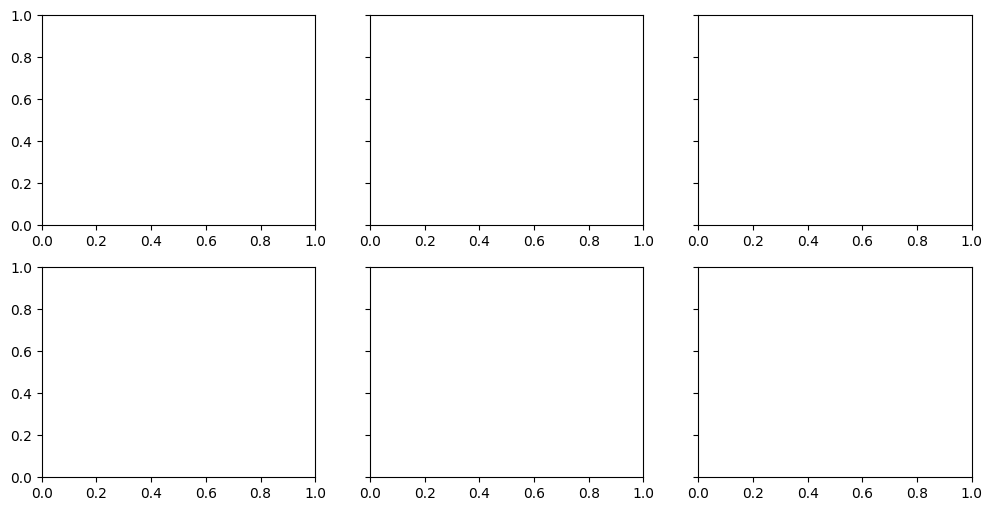

In [678]:
figure , axis = plt.subplots(2,3, sharey = True, figsize = (12,6))

#Customer Satisfaction Distribution

In [679]:
count = data['satisfaction'].value_counts()
axis[0, 0].bar(count.index, count, color = ['steelblue', 'orange'], edgecolor = 'k')

axis[0, 0].set_title('Customer Satisfaction Distribution')
axis[0, 0].set_xlabel('Satisfaction')
axis[0, 0].set_ylabel('Number of Passengers')

axis[0,0].grid(axis = 'y', ls = '--', alpha = 0.5)

#Customer Type Distribution

In [680]:
count = data['Customer Type'].value_counts()
axis[1, 0].bar(count.index, count, color = ['darkgreen', 'darkred'], edgecolor = 'k')

axis[1, 0].set_title('Customer Type Distribution')
axis[1, 0].set_xlabel('Type')
axis[1, 0].set_ylabel('Number of Passengers')

axis[1, 0].grid(axis = 'y', ls = '--', alpha = 0.5)

#Class Distribution

In [681]:
count = data['Class'].value_counts()
axis[0, 1].bar(count.index, count, color = ['gold', 'brown','silver'], edgecolor = 'k')

axis[0, 1].set_title('Class Type Distribution')
axis[0, 1].set_xlabel('Class')

axis[0, 1].grid(axis = 'y', ls = '--', alpha = 0.5)

#Gender Distribution

In [682]:
count = data['Gender'].value_counts()
axis[1, 1].bar(count.index, count, color = ['steelblue', 'pink'], edgecolor = 'k')

axis[1, 1].set_title('Gender Distribution')
axis[1, 1].set_xlabel('Gender')

axis[1, 1].grid(axis = 'y', ls = '--', alpha = 0.5)

#Type of Travel Distribution

In [683]:
count = data['Type of Travel'].value_counts()
axis[1, 2].bar(count.index, count, color = ['gold', 'steelblue'], edgecolor = 'k')

axis[1, 2].set_title('Type of Travel Distribution')
axis[1, 2].set_xlabel('Type of Travel')

axis[1, 2].grid(axis = 'y', ls = '--', alpha = 0.5)

#Departure/Arrival Time Convenient Rating

In [684]:
count = data['Departure/Arrival time convenient'].value_counts()
colors = ['green' if rating >= 3 else 'red' for rating in count.index]

axis[0, 2].bar(count.index, count, color = colors, edgecolor = 'k')

axis[0, 2].set_title('Departure/Arrival Time Convenient Rating Distribution')
axis[0, 2].set_xlabel('Departure/Arrival Time Convenient Rating')

axis[0, 2].grid(axis = 'y', ls = '--', alpha = 0.5)

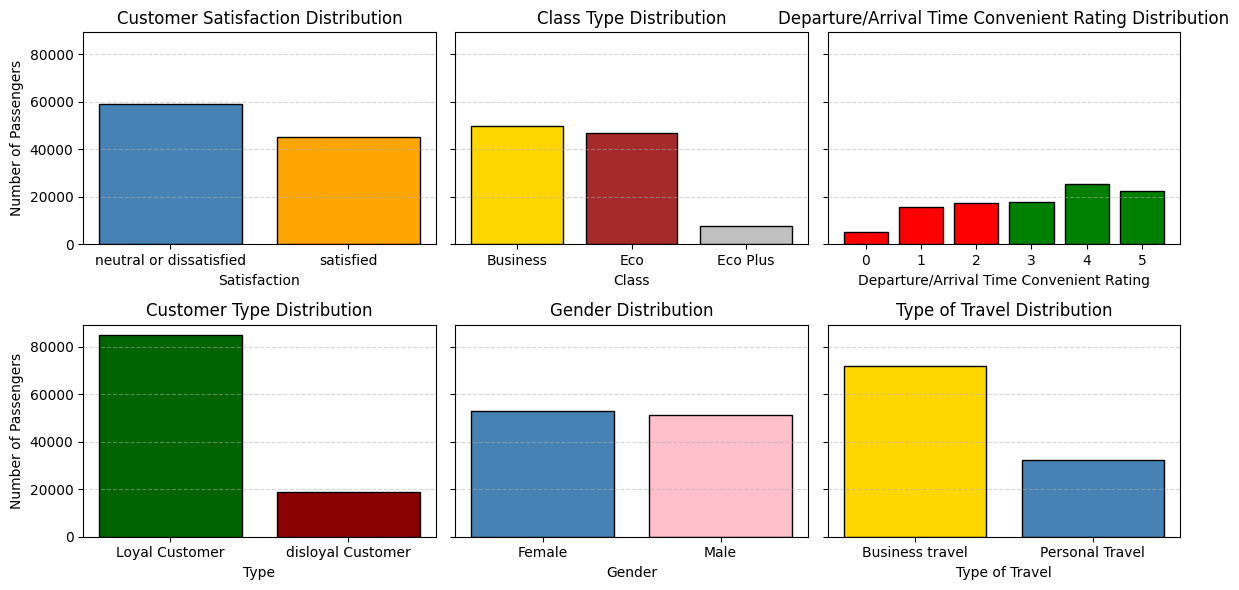

In [685]:
figure.tight_layout()
figure

#Age Distribution

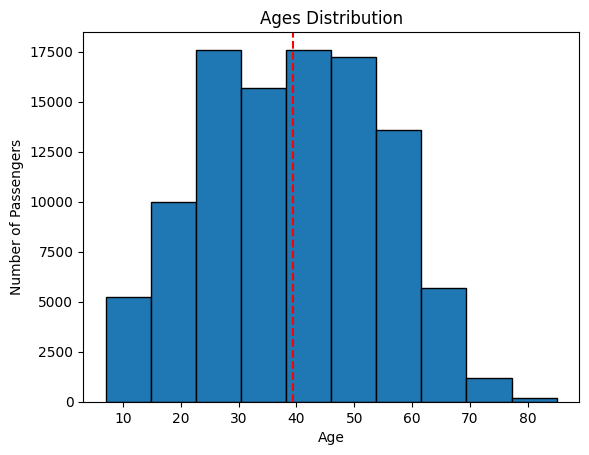

In [686]:
plt.hist(data['Age'], edgecolor ='k')

plt.title('Ages Distribution')
plt.xlabel('Age')
plt.ylabel('Number of Passengers')

plt.axvline(x = data['Age'].mean(), color = 'r', ls = '--')

plt.show()

#Flight Distance Distribution

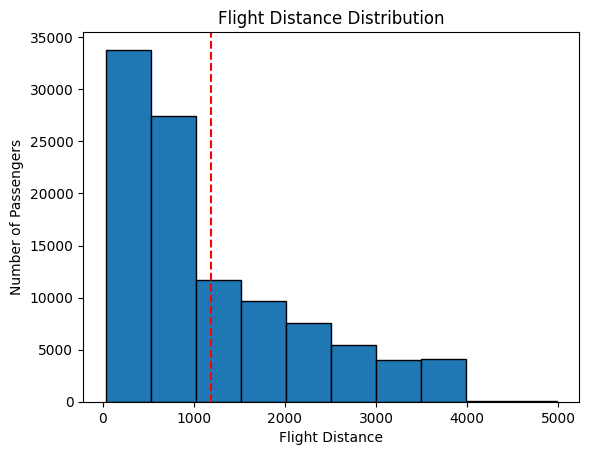

In [687]:
plt.hist(data['Flight Distance'], edgecolor ='k')

plt.title('Flight Distance Distribution')
plt.xlabel('Flight Distance')
plt.ylabel('Number of Passengers')

plt.axvline(x = data['Flight Distance'].mean(), color = 'r', ls = '--')


plt.show()

#Satisfaction Percentage

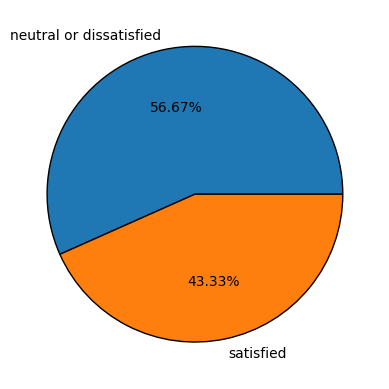

In [688]:
count = data['satisfaction'].value_counts()
plt.pie(count, labels = count.index, autopct = "%1.2f%%", wedgeprops={'edgecolor' : 'k'})
plt.show()

#Departure vs Arrival Delay (Scatter Plot)

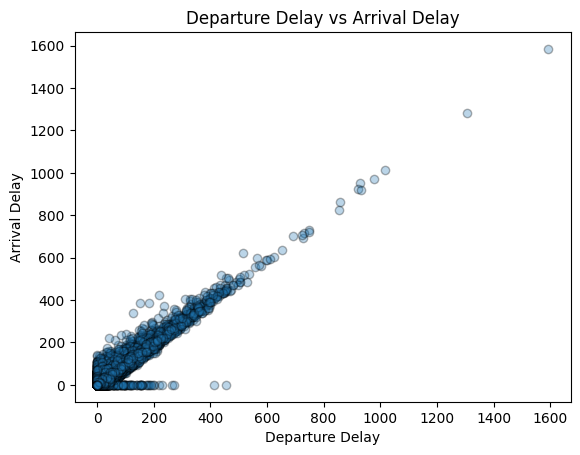

In [697]:
plt.scatter(data['Departure Delay in Minutes'], data['Arrival Delay in Minutes'], alpha = 0.3)

plt.xlabel('Departure Delay')
plt.ylabel('Arrival Delay')
plt.title('Departure Delay vs Arrival Delay')

plt.show()

#Average Service Rating by Class

In [690]:
services = [ 'Inflight wifi service', 'Food and drink', 'Seat comfort', 'Online boarding', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness' ]
avg_class_services = data.groupby('Class')[services].mean().mean(axis = 1)
avg_class_services

,0
Class,
Business,3.565414
Eco,3.105643
Eco Plus,3.101317


Text(0, 0.5, 'Average Rating')

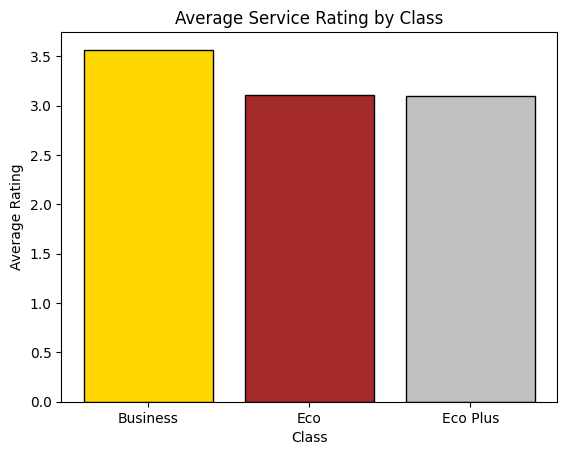

In [698]:
plt.bar(avg_class_services.index, avg_class_services, color = ['gold', 'brown','silver'], edgecolor = 'k')
plt.title('Average Service Rating by Class')
plt.xlabel('Class')
plt.ylabel('Average Rating')

#Average Service Rating

In [692]:
services_avg_rating = data[services].mean().sort_values()
services_avg_rating

,0
Inflight wifi service,2.729683
Food and drink,3.202129
Online boarding,3.250375
Cleanliness,3.286351
Checkin service,3.304290
Leg room service,3.351055
Inflight entertainment,3.358158
On-board service,3.382363
Seat comfort,3.439396
Baggage handling,3.631833


In [ ]:
color = plt.cm

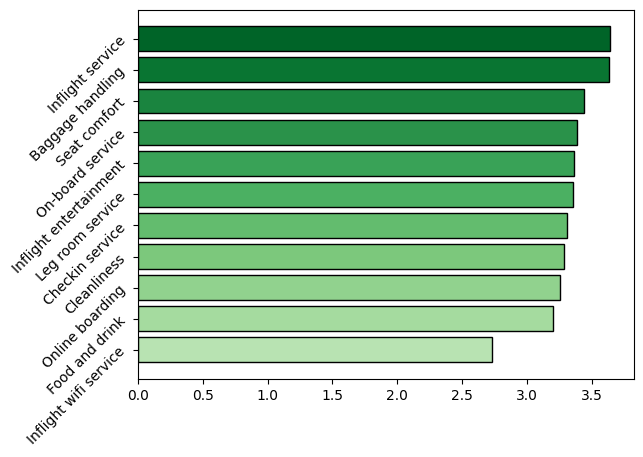

In [702]:
colors = plt.cm.Greens(np.linspace(0.3, 0.9, len(services_avg_rating)))
plt.barh(services_avg_rating.index, services_avg_rating, edgecolor = 'k', color = colors)
plt.yticks(rotation = 45)
plt.show()